<a href="https://colab.research.google.com/github/ShashankSatishkumar/Lasers/blob/main/effectivebgsconvw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:39: SyntaxWarning: invalid escape sequence '\D'
<>:39: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_6165/32107382.py:39: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Frequency Detuning from Resonance, $\Delta\\nu$ (MHz)', fontsize=12)


Monochromatic FWHM:  29.76 MHz 
Lorentzian-Pumped FWHM: 79.52 MHz
Gaussian-Pumped FWHM:   67.52 MHz


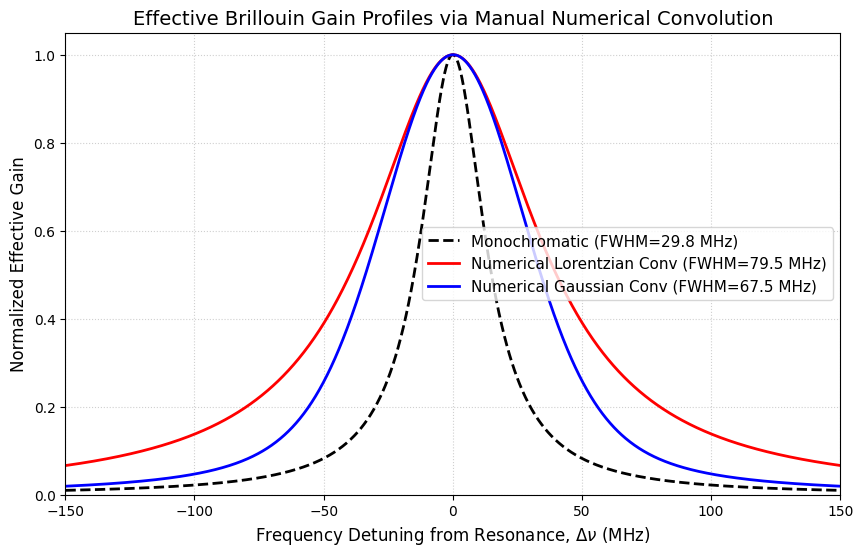

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def fwhm(x,y):
  m_y=np.max(y)
  hm_y=m_y/2.0
  ah=np.where(y>=hm_y)[0]
  fwhm=x[ah[-1]]-x[ah[0]]
  return fwhm
gamma_B=30.0
pump_w=50.0
dif=np.linspace(-500,500,4000)
delnu=dif[1]-dif[0]
mono_gain=(gamma_B/2)**2/((gamma_B / 2)**2 + dif**2)
lor_p = (1 / np.pi) * (pump_w / 2) / ((pump_w / 2)**2 + dif**2)
sigma_p = pump_w/ (2 * np.sqrt(2 * np.log(2)))
gaus_p = (1 / (sigma_p * np.sqrt(2 * np.pi))) * np.exp(-dif**2 / (2 * sigma_p**2))
gain_lor=np.convolve(mono_gain,lor_p,mode='same')*delnu
gain_gaus=np.convolve(mono_gain,gaus_p,mode='same')*delnu
mono_gain=mono_gain/np.max(mono_gain)
gain_lor=gain_lor/np.max(gain_lor)
gain_gaus=gain_gaus/np.max(gain_gaus)
mask= (dif >= -150) & (dif <= 150)
dif = dif[mask]
mono_plt = mono_gain[mask]
lor_plt = gain_lor[mask]
gaus_plt = gain_gaus[mask]
fwhm_mono = fwhm(dif, mono_plt)
fwhm_lorentz = fwhm(dif, lor_plt)
fwhm_gauss = fwhm(dif,gaus_plt)
print(f"Monochromatic FWHM:  {fwhm_mono:.2f} MHz ")
print(f"Lorentzian-Pumped FWHM: {fwhm_lorentz:.2f} MHz")
print(f"Gaussian-Pumped FWHM:   {fwhm_gauss:.2f} MHz")
plt.figure(figsize=(10, 6))
plt.plot(dif, mono_plt, 'k--', label=f'Monochromatic (FWHM={fwhm_mono:.1f} MHz)', linewidth=2)
plt.plot(dif, lor_plt, 'r-', label=f'Numerical Lorentzian Conv (FWHM={fwhm_lorentz:.1f} MHz)', linewidth=2)
plt.plot(dif, gaus_plt, 'b-', label=f'Numerical Gaussian Conv (FWHM={fwhm_gauss:.1f} MHz)', linewidth=2)

plt.title('Effective Brillouin Gain Profiles via Manual Numerical Convolution', fontsize=14)
plt.xlabel('Frequency Detuning from Resonance, $\Delta\\nu$ (MHz)', fontsize=12)
plt.ylabel('Normalized Effective Gain', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim([-150, 150])
plt.ylim([0, 1.05])

plt.show()